In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [4]:
CSV_PATH = "Dress_Color_Dataset/styles.csv"

df = pd.read_csv(CSV_PATH, on_bad_lines="skip")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
print(df.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


In [6]:
print(df.isnull().sum())

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64


In [7]:
print(df["baseColour"].value_counts())

baseColour
Black                9728
White                5538
Blue                 4918
Brown                3494
Grey                 2741
Red                  2455
Green                2115
Pink                 1860
Navy Blue            1789
Purple               1640
Silver               1090
Yellow                778
Beige                 749
Gold                  628
Maroon                581
Orange                530
Olive                 410
Multi                 394
Cream                 390
Steel                 315
Charcoal              228
Peach                 195
Off White             182
Skin                  179
Lavender              162
Grey Melange          146
Khaki                 139
Magenta               129
Teal                  120
Tan                   114
Mustard                97
Bronze                 95
Copper                 86
Turquoise Blue         69
Rust                   66
Burgundy               45
Metallic               43
Coffee Brown           31
M

In [8]:
print(df["articleType"].value_counts())

articleType
Tshirts                7067
Shirts                 3217
Casual Shoes           2845
Watches                2542
Sports Shoes           2036
                       ... 
Cushion Covers            1
Mens Grooming Kit         1
Body Wash and Scrub       1
Suits                     1
Ipad                      1
Name: count, Length: 143, dtype: int64


In [9]:
# Clothing articles only
clothing_articles = [
    "Tshirts",
    "Shirts",
    "Kurtas",
    "Tops",
    "Dresses",
    "Jeans",
    "Trousers",
    "Track Pants",
    "Shorts",
    "Jackets",
    "Sweaters",
    "Sweatshirts",
    "Blazers",
    "Skirts",
    "Leggings",
    "Dupatta",
    "Kurta Sets",
    "Tunics",
    "Shrug",
    "Waistcoat",
    "Capris"
]

df = df[df["articleType"].isin(clothing_articles)]

print("Remaining Images:", len(df))

Remaining Images: 18112


In [10]:
selected_colors = [
    "Black",
    "White",
    "Blue",
    "Brown",
    "Grey",
    "Red",
    "Green",
    "Pink",
    "Purple",
    "Yellow"
]

df = df[df["baseColour"].isin(selected_colors)]

print(df["baseColour"].value_counts())

baseColour
Blue      3151
Black     2655
White     2366
Grey      1393
Green     1306
Red       1231
Pink       891
Purple     883
Yellow     513
Brown      478
Name: count, dtype: int64


In [11]:
df = df.dropna(subset=["baseColour"])

print(df.isnull().sum())

id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                1
year                  1
usage                 2
productDisplayName    0
dtype: int64


In [12]:
IMAGE_FOLDER = "Dress_Color_Dataset/images"

def image_exists(image_id):
    return os.path.exists(
        os.path.join(IMAGE_FOLDER, f"{image_id}.jpg")
    )

df["image_exists"] = df["id"].apply(image_exists)

df = df[df["image_exists"]]

print("Valid Images:", len(df))

Valid Images: 14864


In [13]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["baseColour"]
)

print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))

Training Images: 11891
Validation Images: 2973


In [14]:
IMAGE_SIZE = (128, 128)

BATCH_SIZE = 16

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [24]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [22]:
df["filename"] = df["id"].astype(str) + ".jpg"

In [26]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["baseColour"]
)

In [27]:
print(train_df.columns)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName',
       'image_exists', 'filename'],
      dtype='object')


In [28]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_FOLDER,
    x_col="filename",
    y_col="baseColour",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_FOLDER,
    x_col="filename",
    y_col="baseColour",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 11891 validated image filenames belonging to 10 classes.
Found 2973 validated image filenames belonging to 10 classes.


In [29]:
# Step 13: Build the MobileNetV2 Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze pretrained layers
base_model.trainable = False


In [30]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(
    len(train_generator.class_indices),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [31]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 64, 64, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 64, 64, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 64, 64, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 64, 64, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 64, 64, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 64, 64, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 64, 64, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 64, 64, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 64, 64, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 64, 64, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 64, 64, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 65, 65, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 32, 32, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,589,514 (9.88 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [33]:
import os

os.makedirs("models", exist_ok=True)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "models/dress_color_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [34]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.2388 - loss: 2.5875
Epoch 1: val_accuracy improved from None to 0.47057, saving model to models/dress_color_model.keras

Epoch 1: finished saving model to models/dress_color_model.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 315s 416ms/step - accuracy: 0.3313 - loss: 2.1971 - val_accuracy: 0.4706 - val_loss: 1.6170
Epoch 2/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.4547 - loss: 1.7264
Epoch 2: val_accuracy improved from 0.47057 to 0.54120, saving model to models/dress_color_model.keras

Epoch 2: finished saving model to models/dress_color_model.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 158s 213ms/step - accuracy: 0.4706 - loss: 1.6737 - val_accuracy: 0.5412 - val_loss: 1.4121
Epoch 3/10
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5143 - loss: 1.5025
Epoch 3: val_accuracy improved from 0.54120 to 0.56811, saving model to models/dress_color_model.keras

Epoch 3: finished saving model to models/dress_color_mo

In [35]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

186/186 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.6125 - loss: 1.1725
Validation Loss: 1.1725223064422607
Validation Accuracy: 0.6125125885009766


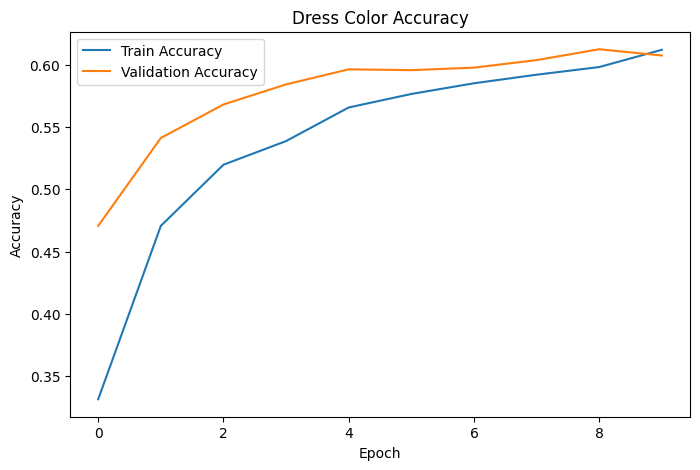

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dress Color Accuracy")
plt.legend()

plt.show()

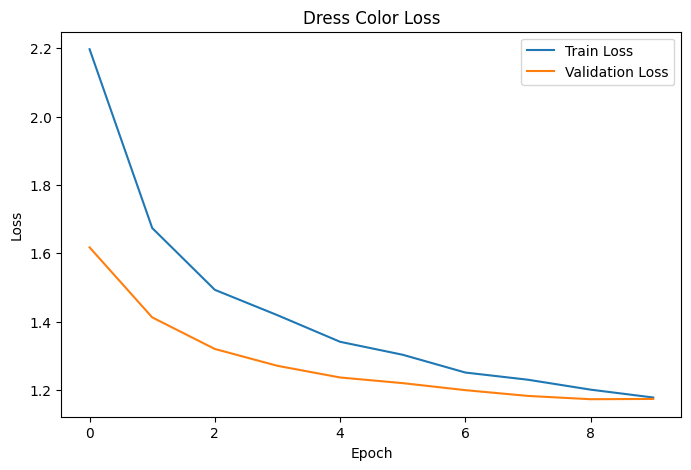

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dress Color Loss")
plt.legend()

plt.show()

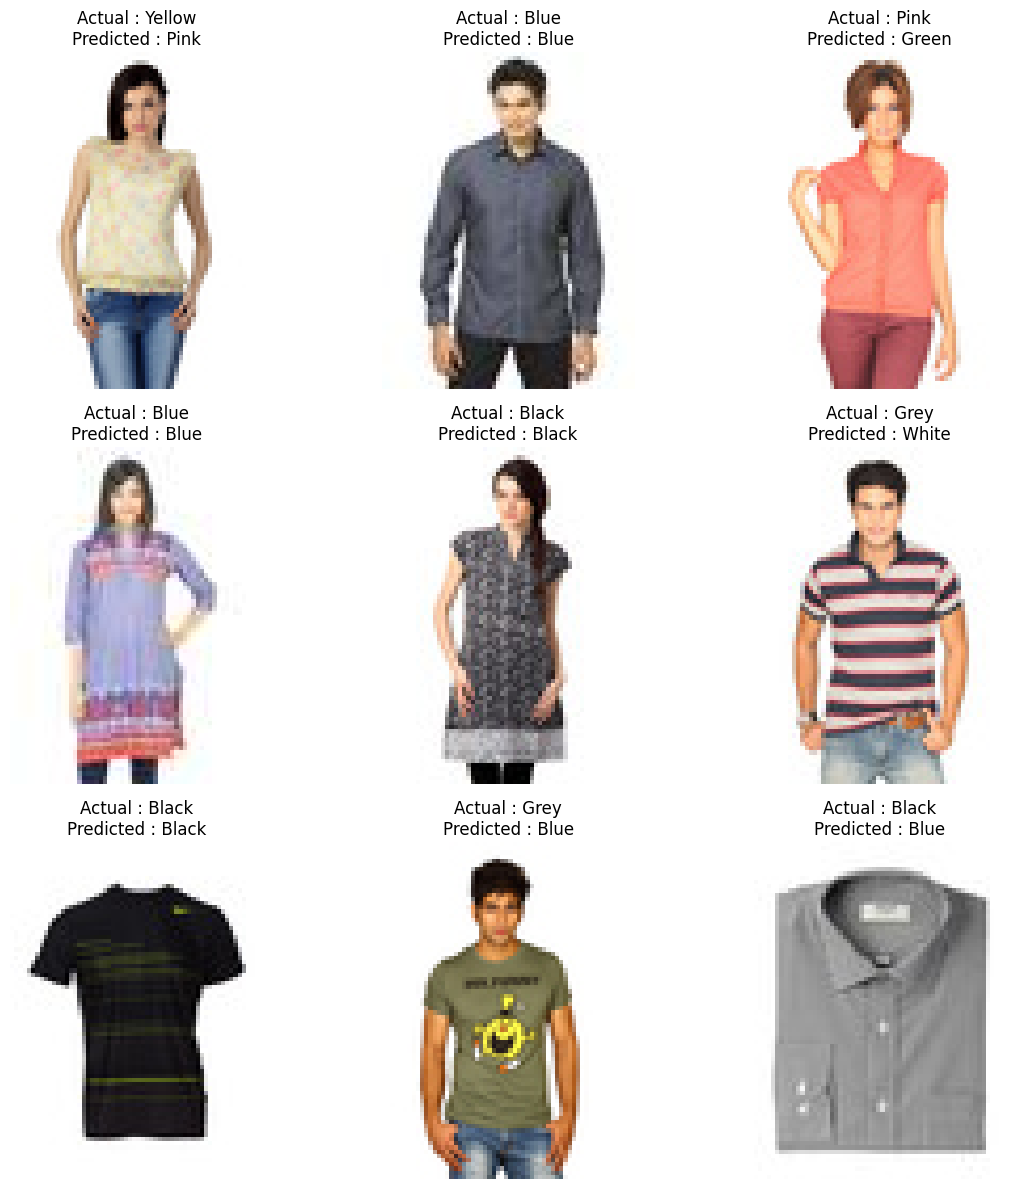

In [38]:
import random

sample = val_df.sample(9, random_state=42)

plt.figure(figsize=(12,12))

class_names = list(train_generator.class_indices.keys())

for i, (_, row) in enumerate(sample.iterrows()):

    img_path = os.path.join(IMAGE_FOLDER, row["filename"])

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    input_img = cv2.resize(img_rgb, (128,128))
    input_img = input_img.astype("float32") / 255.0
    input_img = np.expand_dims(input_img, axis=0)

    prediction = model.predict(input_img, verbose=0)

    predicted = class_names[np.argmax(prediction)]

    plt.subplot(3,3,i+1)
    plt.imshow(img_rgb)
    plt.title(f"Actual : {row['baseColour']}\nPredicted : {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = val_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

186/186 ━━━━━━━━━━━━━━━━━━━━ 52s 261ms/step
              precision    recall  f1-score   support

       Black       0.68      0.80      0.74       531
        Blue       0.54      0.77      0.64       630
       Brown       0.32      0.24      0.27        95
       Green       0.70      0.42      0.53       261
        Grey       0.47      0.36      0.41       279
        Pink       0.54      0.37      0.44       178
      Purple       0.46      0.19      0.27       177
         Red       0.63      0.76      0.69       246
       White       0.73      0.69      0.71       473
      Yellow       0.85      0.68      0.76       103

    accuracy                           0.61      2973
   macro avg       0.59      0.53      0.54      2973
weighted avg       0.61      0.61      0.60      2973



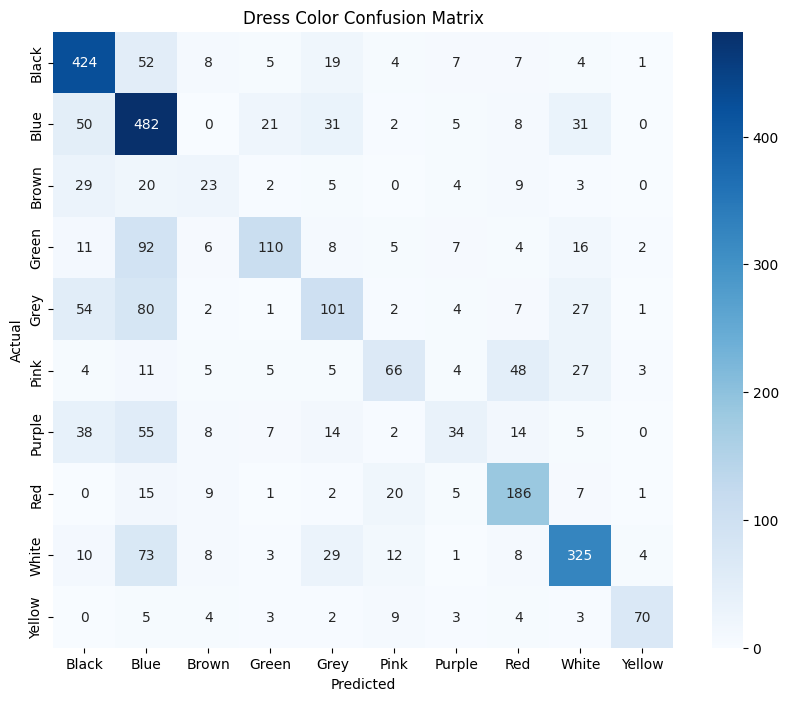

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(train_generator.class_indices.keys()),
    yticklabels=list(train_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dress Color Confusion Matrix")

plt.show()

In [41]:
model.save("models/dress_color_model.keras")

print("Dress Color Model Saved Successfully!")

Dress Color Model Saved Successfully!


In [42]:
from tensorflow.keras.models import load_model

loaded_model = load_model("models/dress_color_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!
